# Skip-gram (Word Embedding)

In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Memuat Dataset & Tokenisasi

Tahap ini memuat file detik_preprocessed.csv hasil preprocessing. Teks berita dipastikan bersih lalu diubah menjadi list kata (tokens) agar siap diproses oleh algoritma Word2Vec Skip-gram.

In [14]:
# 1. Memuat dataset preprocessed
df = pd.read_csv('detik_preprocessed.csv')
df['isi_berita_clean'] = df['isi_berita_clean'].fillna('')

# 2. Mengubah teks berita menjadi list kata (tokens) dan label ke angka
df['tokens'] = df['isi_berita_clean'].apply(lambda x: x.split())
df['label_encoded'] = df['label'].map({'finance': 0, 'sport': 1})

# Variabel sentences & labels untuk proses selanjutnya
sentences = df['tokens'].tolist()
labels = df['label_encoded'].values

print("Selesai memuat dataset dan melakukan tokenisasi kalimat...\n")

# 3. Menampilkan 5 baris pertama tabel dataset
print("--- Tabel Dataset Preprocessed & Tokenisasi ---")
display(df[['id', 'isi_berita_clean', 'tokens', 'label', 'label_encoded']].head())

Selesai memuat dataset dan melakukan tokenisasi kalimat...

--- Tabel Dataset Preprocessed & Tokenisasi ---


,id,isi_berita_clean,tokens,label,label_encoded
0,1,ketua umum komite olahraga nasional indonesia ...,"[ketua, umum, komite, olahraga, nasional, indo...",sport,1
1,2,urus pusat kickboxing indonesia pp kbi periode...,"[urus, pusat, kickboxing, indonesia, pp, kbi, ...",sport,1
2,3,lina hisage atlet tolak peluru asal wamena pap...,"[lina, hisage, atlet, tolak, peluru, asal, wam...",sport,1
3,4,timnas equestrian indonesia tolak jepang jelan...,"[timnas, equestrian, indonesia, tolak, jepang,...",sport,1
4,5,dua seri akhir motogp marc marquez sukses sapu...,"[dua, seri, akhir, motogp, marc, marquez, suks...",sport,1


In [15]:
# Ringkasan statistik dan distribusi label
print(f"• Total Baris Data : {len(df)} berita")
print(f"• Distribusi Label :\n{df['label'].value_counts().to_string()}")

• Total Baris Data : 200 berita
• Distribusi Label :
label
sport      100
finance    100


### Melatih Model Skip-gram (Word2Vec)

Tahap ini melatih arsitektur Skip-gram untuk merubah setiap kata unik menjadi vektor berdimensi 100. Skip-gram memprediksi kata konteks di sekitar kata target berdasarkan pola hubungan semantik.

In [6]:
from gensim.models import Word2Vec

In [8]:
# Melatih model Word2Vec Skip-gram (sg=1)
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    workers=4,
    seed=42
)

print(f"Selesai melatih model Skip-gram dengan {len(w2v_model.wv)} kata unik...")

Selesai melatih model Skip-gram dengan 5328 kata unik...


In [16]:
# 1. STATISTIK RINGKAS HASIL PELATIHAN
vocab_size = len(w2v_model.wv)
vector_dim = w2v_model.wv.vector_size

print("--- Statistik Hasil Pelatihan WORD2VEC (Skip-Gram) ---")
print(f"• Total Kosakata Unik (Vocabulary Size) : {vocab_size} kata")
print(f"• Dimensi Vektor per Kata               : {vector_dim} dimensi\n")

# 2. CONTOH REPRESENTASI VEKTOR KATA
# Mengambil sampel kata yang ada di dalam vokabulari
sample_word = 'olahraga' if 'olahraga' in w2v_model.wv else list(w2v_model.wv.index_to_key)[0]

print(f"--- Contoh Nilai Vektor Kata ('{sample_word}') ---")
print(f"• Bentuk Array (Shape) : {w2v_model.wv[sample_word].shape}")
print(f"• 10 Nilai Pertama     :\n{w2v_model.wv[sample_word][:10]}\n")

# 3. KATA PALING MIRIP (MOST SIMILAR WORDS)
print(f"--- 5 Kata Terdekat Atau Paling Mirip Dengan '{sample_word}' ---")
similar_words = w2v_model.wv.most_similar(sample_word, topn=5)
for word, score in similar_words:
    print(f"• {word:<15} (Cos Similarity: {score:.4f} / {score*100:.2f}%)")

# 4. SKOR KEMIRIPAN (COSINE SIMILARITY) ANTAR DUA KATA
word1, word2 = 'atlet', 'juara'
if word1 in w2v_model.wv and word2 in w2v_model.wv:
    sim_score = w2v_model.wv.similarity(word1, word2)
    print(f"\n--- Tingkat Kemiripan Antara '{word1}' & '{word2}' ---")
    print(f"• Skor Cosine Similarity: {sim_score:.4f} ({sim_score*100:.2f}%)")

--- Statistik Hasil Pelatihan WORD2VEC (Skip-Gram) ---
• Total Kosakata Unik (Vocabulary Size) : 5328 kata
• Dimensi Vektor per Kata               : 100 dimensi

--- Contoh Nilai Vektor Kata ('olahraga') ---
• Bentuk Array (Shape) : (100,)
• 10 Nilai Pertama     :
[-0.08234148 -0.0450739  -0.19603175  0.09195485 -0.05598317  0.40699798
  0.01201053  0.17012846  0.25069505  0.21247457]

--- 5 Kata Terdekat Atau Paling Mirip Dengan 'olahraga' ---
• para            (Cos Similarity: 0.9820 / 98.20%)
• bina            (Cos Similarity: 0.9798 / 97.98%)
• sektor          (Cos Similarity: 0.9774 / 97.74%)
• ajar            (Cos Similarity: 0.9732 / 97.32%)
• harap           (Cos Similarity: 0.9713 / 97.13%)

--- Tingkat Kemiripan Antara 'atlet' & 'juara' ---
• Skor Cosine Similarity: 0.6511 (65.11%)


### Membuat Vektor Dokumen (Average Word Vector)

Menggabungkan seluruh vektor kata dalam satu berita dengan menghitung rata-ratanya (Average Word Vector). Hasilnya adalah satu vektor tunggal berdimensi 100 yang mewakili isi keseluruhan berita.

In [9]:
# Fungsi menghitung rata-rata vektor kata per dokumen
def get_document_vector(tokens, model):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)

# Membuat matriks vektor dokumen
X_vec = np.array([get_document_vector(doc, w2v_model) for doc in sentences])

print(f"Selesai membuat Vektor Dokumen berukuran {X_vec.shape}...")

Selesai membuat Vektor Dokumen berukuran (200, 100)...


In [17]:
# 1. Konversi matriks X_vec ke pandas DataFrame
vec_cols = [f'dim_{i+1}' for i in range(X_vec.shape[1])]
df_doc_vec = pd.DataFrame(X_vec, columns=vec_cols)

# 2. Sisipkan kembali kolom 'id' dan 'label' dari dataframe awal
df_doc_vec.insert(0, 'label', df['label'])
df_doc_vec.insert(0, 'id', df['id'])

# 3. Tampilkan Informasi Ukuran Matriks
print("--- Informasi Hasil Vektor Dokumen (Skip-Gram) ---")
print(f"• Total Dokumen/Berita   : {X_vec.shape[0]} baris")
print(f"• Dimensi Vektor Dokumen : {X_vec.shape[1]} dimensi/fitur\n")

# 4. Tampilkan 5 baris pertama tabel (menampilkan 6 dimensi pertama)
print("--- Tabel Hasil Vektor Dokumen (5 Baris Pertama) ---")
display(df_doc_vec[['id', 'label'] + vec_cols[:6]].head())

# 5. Opsional: Simpan hasil vektor ke file CSV
df_doc_vec.to_csv('detik_skipgram_doc_vectors.csv', index=False, encoding='utf-8-sig')
print("\nVektor dokumen berhasil disimpan ke 'detik_skipgram_doc_vectors.csv'")

--- Informasi Hasil Vektor Dokumen (Skip-Gram) ---
• Total Dokumen/Berita   : 200 baris
• Dimensi Vektor Dokumen : 100 dimensi/fitur

--- Tabel Hasil Vektor Dokumen (5 Baris Pertama) ---


,id,label,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6
0,1,sport,-0.007833,-0.075368,-0.089521,0.010501,-0.040347,0.243844
1,2,sport,-0.007692,-0.089503,-0.111302,0.016007,-0.029429,0.279093
2,3,sport,0.001453,-0.097025,-0.107161,0.013161,-0.023965,0.263947
3,4,sport,0.007492,-0.078524,-0.106336,0.030866,-0.007872,0.246577
4,5,sport,0.046891,-0.171653,-0.046753,-0.114423,-0.035822,0.228717



Vektor dokumen berhasil disimpan ke 'detik_skipgram_doc_vectors.csv'


### Pembagian Data (Train-Test Split)

Membagi vektor berita menjadi 80% data latih dan 20% data uji. Pembagian ini menggunakan stratify agar proporsi kelas Finance dan Sport tetap seimbang pada kedua bagian.

In [ ]:
# Pembagian data 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, labels, test_size=0.20, random_state=42, stratify=labels
)

print(f"Selesai membagi data: {len(X_train)} Train dan {len(X_test)} Test...")

Selesai membagi data: 160 Train dan 40 Test...


In [18]:
# 1. Pembagian data 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, labels, test_size=0.20, random_state=42, stratify=labels
)

# 2. Menghitung distribusi kelas (0: Finance, 1: Sport)
train_dist = pd.Series(y_train).value_counts().rename({0: 'Finance (0)', 1: 'Sport (1)'})
test_dist = pd.Series(y_test).value_counts().rename({0: 'Finance (0)', 1: 'Sport (1)'})

# 3. Menampilkan Ringkasan Informasi Pembagian Data
print("--- Ringkasan Pembagian Dataset (80:20) ---")
print(f"• Total Data Awal     : {len(X_vec)} berita")
print(f"• Data Training (80%) : {X_train.shape[0]} baris (Bentuk Matriks: {X_train.shape})")
print(f"• Data Testing  (20%) : {X_test.shape[0]} baris (Bentuk Matriks: {X_test.shape})\n")

# 4. Menampilkan Tabel Distribusi Kelas
df_split_info = pd.DataFrame({
    'Data Training (80%)': train_dist,
    'Data Testing (20%)': test_dist,
    'Total Dataset': train_dist + test_dist
})

print("--- Tabel Distribusi Kelas ---")
display(df_split_info)

--- Ringkasan Pembagian Dataset (80:20) ---
• Total Data Awal     : 200 berita
• Data Training (80%) : 160 baris (Bentuk Matriks: (160, 100))
• Data Testing  (20%) : 40 baris (Bentuk Matriks: (40, 100))

--- Tabel Distribusi Kelas ---


,Data Training (80%),Data Testing (20%),Total Dataset
Finance (0),80,20,100
Sport (1),80,20,100


### Reduksi Dimensi dengan PCA

Mengompresi dimensi vektor data latih menggunakan PCA untuk mempertahankan 85% varians informasi. Vektor data uji kemudian ditransformasikan menggunakan parameter PCA dari data latih tersebut.

In [21]:
# Reduksi dimensi dengan PCA (mempertahankan 85% varians)
pca = PCA(n_components=0.85, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Selesai reduksi PCA: dari {X_train.shape[1]}D menjadi {X_train_pca.shape[1]}D...")

Selesai reduksi PCA: dari 100D menjadi 3D...


In [22]:
# Tahap 1: Fit & Transform PCA
# Inisialisasi PCA dengan target mempertahankan 85% varians informasi
pca = PCA(n_components=0.85, random_state=42)

# Fit & Transform hanya pada data training, kemudian Transform pada data testing
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Tahap 2: Menampilkan Statistik Hasil Reduksi
n_fitur_awal = X_train.shape[1]
n_fitur_pca = X_train_pca.shape[1]
cum_variance = np.sum(pca.explained_variance_ratio_) * 100

print("--- Statistik Hasil Reduksi Dimensi PCA ---")
print(f"• Jumlah Dimensi Awal (Skip-gram) : {n_fitur_awal} dimensi")
print(f"• Jumlah Dimensi Hasil PCA        : {n_fitur_pca} komponen utama (PC)")
print(f"• Persentase Informasi Terjaga    : {cum_variance:.2f}% (Target: >= 85%)\n")

print("--- Ukuran Matriks Setelah PCA ---")
print(f"• Shape X_train_pca : {X_train_pca.shape}")
print(f"• Shape X_test_pca  : {X_test_pca.shape}\n")

# Tahap 3: Menampilkan Tabel Komponen Utama (PC)
# Membuat DataFrame dari matriks X_train_pca
pc_cols = [f'PC{i+1}' for i in range(n_fitur_pca)]
df_pca_train = pd.DataFrame(X_train_pca, columns=pc_cols)

print("--- Tabel 5 Baris Pertama Hasil PCA Data Training ---")
display(df_pca_train.head())

--- Statistik Hasil Reduksi Dimensi PCA ---
• Jumlah Dimensi Awal (Skip-gram) : 100 dimensi
• Jumlah Dimensi Hasil PCA        : 3 komponen utama (PC)
• Persentase Informasi Terjaga    : 90.96% (Target: >= 85%)

--- Ukuran Matriks Setelah PCA ---
• Shape X_train_pca : (160, 3)
• Shape X_test_pca  : (40, 3)

--- Tabel 5 Baris Pertama Hasil PCA Data Training ---


,PC1,PC2,PC3
0,0.246760,-0.098206,0.003116
1,-0.537809,0.055244,-0.034888
2,0.173424,-0.127109,-0.089696
3,0.156303,-0.080093,0.015774
4,-0.624977,0.041956,0.028587


### Pelatihan Model Gaussian Naive Bayes

Melatih algoritma Gaussian Naive Bayes menggunakan data latih hasil reduksi PCA. Model dipelajari untuk mengenali pola probabilitas fitur kontinu dalam membedakan kategori berita.

In [23]:
# Melatih model Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_pca, y_train)

# Prediksi data uji
y_pred = nb_model.predict(X_test_pca)

print("Selesai melakukan pelatihan dan prediksi dengan Gaussian Naive Bayes...")

Selesai melakukan pelatihan dan prediksi dengan Gaussian Naive Bayes...


### Evaluasi Model & Confusion Matrix

Menguji performa model pada data uji, lalu menampilkan akurasi, laporan klasifikasi, dan Confusion Matrix untuk melihat ketepatan prediksi kelas Finance dan Sport secara detail.

Akurasi: 85.00%

              precision    recall  f1-score   support

     Finance       1.00      0.70      0.82        20
       Sport       0.77      1.00      0.87        20

    accuracy                           0.85        40
   macro avg       0.88      0.85      0.85        40
weighted avg       0.88      0.85      0.85        40



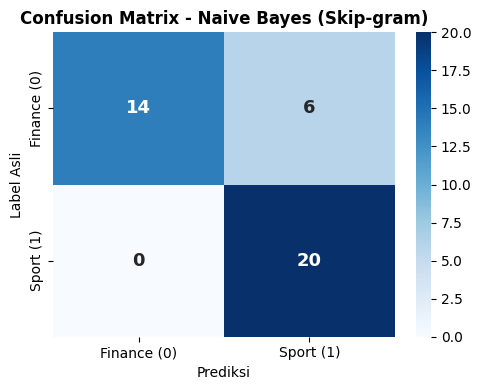

Selesai menampilkan hasil evaluasi dan Confusion Matrix...


In [24]:
# Evaluasi Akurasi dan Laporan Klasifikasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi: {acc * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Finance', 'Sport']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Finance (0)', 'Sport (1)'],
            yticklabels=['Finance (0)', 'Sport (1)'],
            annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix - Naive Bayes (Skip-gram)', fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Label Asli')
plt.tight_layout()
plt.show()

print("Selesai menampilkan hasil evaluasi dan Confusion Matrix...")